In [6]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from xgboost import XGBClassifier
import shap
import joblib


In [7]:
DATA_PATH = "../heart_hrv_cleaned.csv"
OUTPUT_DIR = "final_model_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)
print("Dataset Loaded:", df.shape)

# MAP LABELS → FINAL 4 CLASSES


def map_label(row):
    if isinstance(row["label"], (int, np.integer)):
        mapping = {0: "Arrhythmia", 1: "CAD", 2: "MI", 3: "Normal"}
        return mapping.get(row["label"], None)
    return None

df["target_label"] = df.apply(map_label, axis=1)
df = df[df["target_label"].notna()].copy()

print("Class Distribution:")
print(df["target_label"].value_counts())



Dataset Loaded: (921, 85)
Class Distribution:
target_label
Normal        282
MI            239
Arrhythmia    228
CAD           172
Name: count, dtype: int64


In [8]:
valid_hrv_features = [
    "HRV_MeanNN",
    "HRV_SDNN",
    "HRV_RMSSD",
    "HRV_SDSD",
    "HRV_pNN50",
    "HRV_TINN",
    "HRV_LZC"
]

valid_hrv_features = [f for f in valid_hrv_features if f in df.columns]

X = df[valid_hrv_features].copy()
y = df["target_label"].copy()

print("Final HRV Feature Count:", len(valid_hrv_features))

Final HRV Feature Count: 7


In [9]:
preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X_processed = preprocessor.fit_transform(X)

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Label Encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

Label Encoding: {'Arrhythmia': np.int64(0), 'CAD': np.int64(1), 'MI': np.int64(2), 'Normal': np.int64(3)}


In [10]:
rf_cv = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    rf_cv,
    X_processed,
    y_encoded,
    cv=cv,
    scoring="accuracy"
)

print("\n5-Fold CV Accuracy:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("Std Dev:", cv_scores.std())


5-Fold CV Accuracy: [0.83783784 0.79891304 0.84782609 0.80434783 0.79891304]
Mean CV Accuracy: 0.8175675675675675
Std Dev: 0.020962852645824488


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    eval_metric="mlogloss",
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

lr = LogisticRegression(max_iter=500, random_state=42)

ensemble = VotingClassifier(
    estimators=[("xgb", xgb), ("rf", rf), ("lr", lr)],
    voting="soft"
)

print("\nTraining Ensemble Model...")
ensemble.fit(X_train, y_train)


Training Ensemble Model...


,estimators,"[('xgb', ...), ('rf', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None



Test Accuracy: 0.7621621621621621

Classification Report:
              precision    recall  f1-score   support

  Arrhythmia       0.71      0.43      0.54        46
         CAD       0.71      0.65      0.68        34
          MI       0.89      1.00      0.94        48
      Normal       0.71      0.89      0.79        57

    accuracy                           0.76       185
   macro avg       0.76      0.74      0.74       185
weighted avg       0.76      0.76      0.75       185



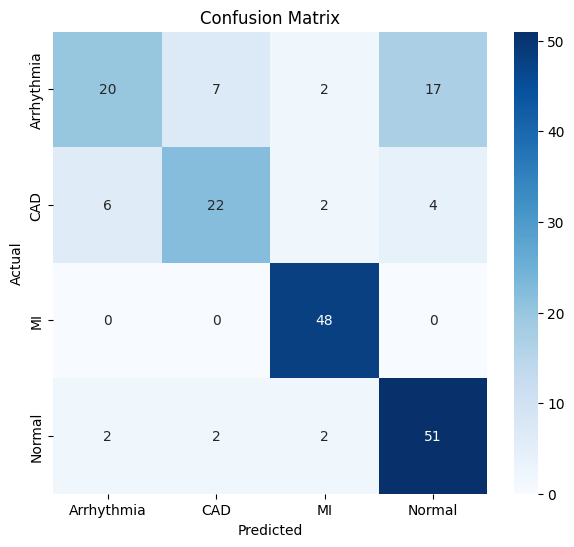

In [12]:
y_pred = ensemble.predict(X_test)
y_prob = ensemble.predict_proba(X_test)

print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [19]:
print(type(shap_values))
if isinstance(shap_values, list):
    print("List length:", len(shap_values))
    print("Shape per class:", shap_values[0].shape)
else:
    print("Array shape:", shap_values.shape)

print("X_test_df shape:", X_test_df.shape)


<class 'numpy.ndarray'>
Array shape: (185, 7, 4)
X_test_df shape: (185, 7)



Computing SHAP Explainability (Random Forest)...


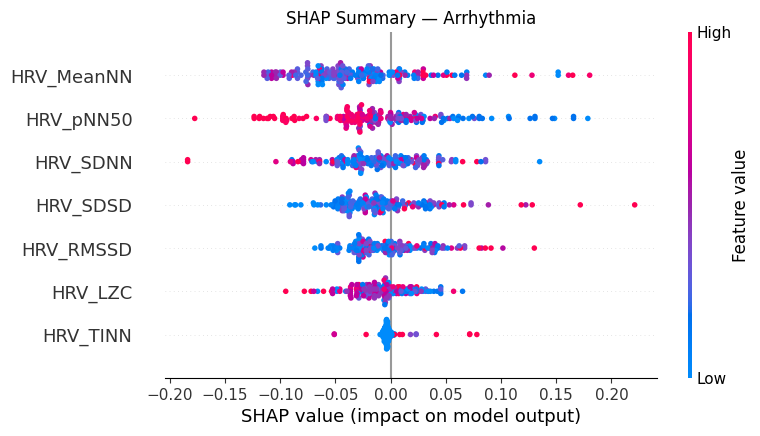

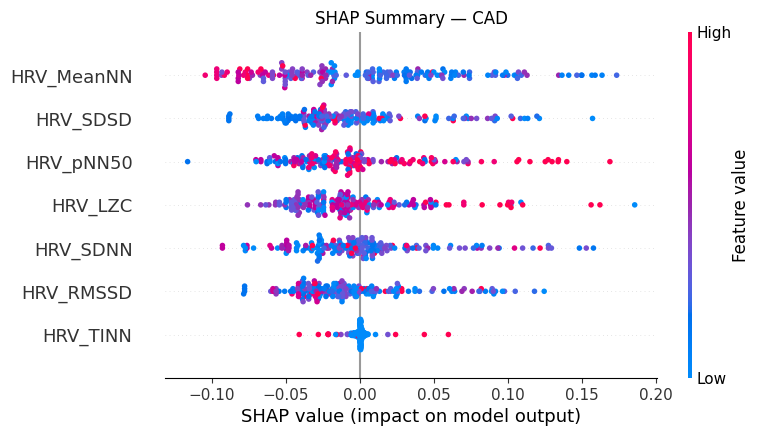

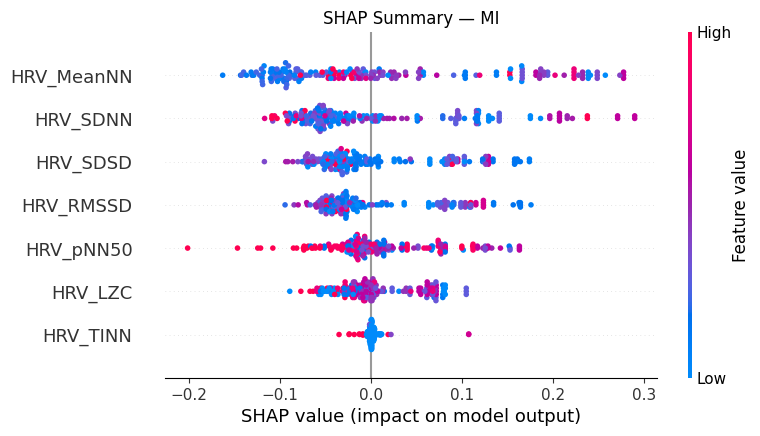

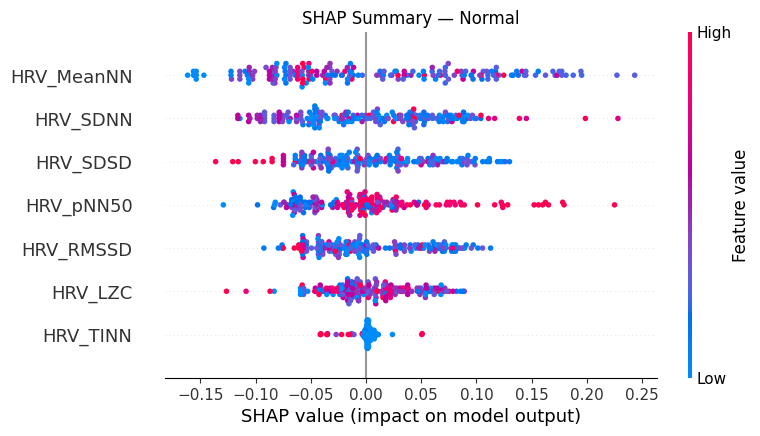

In [20]:
print("\nComputing SHAP Explainability (Random Forest)...")

rf.fit(X_train, y_train)

X_test_df = pd.DataFrame(X_test, columns=valid_hrv_features)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_df)

# shap_values shape = (n_samples, n_features, n_classes)

for i, cls in enumerate(le.classes_):
    shap.summary_plot(
        shap_values[:, :, i],   # ✅ correct slicing
        X_test_df,
        feature_names=valid_hrv_features,
        show=False
    )
    plt.title(f"SHAP Summary — {cls}")
    plt.show()


In [21]:
joblib.dump(ensemble, os.path.join(OUTPUT_DIR, "hrv_ensemble_model.pkl"))
joblib.dump(preprocessor, os.path.join(OUTPUT_DIR, "preprocessor.pkl"))
joblib.dump(le, os.path.join(OUTPUT_DIR, "label_encoder.pkl"))
joblib.dump(valid_hrv_features, os.path.join(OUTPUT_DIR, "features.pkl"))

print("\nAll models and artifacts saved to:", OUTPUT_DIR)



All models and artifacts saved to: final_model_output


In [22]:
def predict_hrv_sample(sample_df):
    sample = sample_df[valid_hrv_features].copy()
    sample_processed = preprocessor.transform(sample)
    probs = ensemble.predict_proba(sample_processed)[0]
    pred_idx = np.argmax(probs)
    return {
        "Predicted Disease": le.inverse_transform([pred_idx])[0],
        "Probabilities": dict(zip(le.classes_, probs))
    }

print("\nPipeline Complete")


Pipeline Complete
